<a href="https://colab.research.google.com/github/trangtranha28/econ3916-lab02-deflation/blob/main/lab_ch02_guided.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Measurement & Indexes — Deflating History
## ECON 3916: Applied Machine Learning for Economists
### Guided Construction Lab | 8 min Part 0 + 45 min Core + 10 min optional API section

---

**Learning Objectives:**
- Pull real FRED time series into pandas — first with no credential at all, then with your own API key
- Build a reusable `deflate_series()` function from scratch
- Plot the fifty-year divergence between nominal and real wages
- Deflate Big Mac prices to separate inflation from a real price change

**Dataset:** FRED (CPIAUCSL, AHETPI) and The Economist's Big Mac Index

**Foundations First Policy:** Parts 1-3 are GUIDED (run as-is, interpret results).
Part 4 has YOUR TASK sections (fill in the blanks). Part 5 is optional.

**Prerequisites:** Part 0 of this lab (below), plus Lab 1 (pandas on real data), Chapter 2
reading (CPI, deflation, Goodhart's Law)

---

## Before you start: FRED, and what an API key is

**FRED** — Federal Reserve Economic Data, run by the St. Louis Fed — publishes over
800,000 economic time series for free. This lab uses two of them: the Consumer Price
Index (`CPIAUCSL`) and average hourly earnings (`AHETPI`).

There are two ways to get data out of FRED, and this lab shows you both.

**Route 1 — the CSV endpoint. No account, no key, nothing to sign up for.**
FRED will hand any series to `pandas.read_csv()` from a plain URL. This is what the
lab uses for every pull below, so **you can complete this entire lab without a
credential.** Nothing here is blocked on paperwork.

**Route 2 — the API, with your own key.** Part 5 is optional and shows the same
data pulled through the `fredapi` package. That route needs an API key.

### What an API key actually is

An **API key** is a long string of letters and numbers that identifies *you* to a
data provider's server — a library card number for a database. The server uses it
to see who is asking, count your requests, and cut you off if you hammer it. It is
not a password to your computer and it is not secret in the way a bank password is,
but it *is* tied to your account, so you do not publish it.

### Getting one (about two minutes)

1. Go to <https://fredaccount.stlouisfed.org/login/secure/> and click
   **Create New Account**. It is free and needs only an email address.
2. Check your email and click the confirmation link.
3. Signed in, go to <https://fredaccount.stlouisfed.org/apikeys> and click
   **Request API Key**.
4. Type anything reasonable in the description box ("ECON 3916 coursework") and
   submit.
5. Your key appears on that page immediately — a 32-character lowercase string. It
   also arrives by email. Copy it.
6. Paste it into the optional Part 5 cell, **between the quotation marks**, replacing
   the words `YOUR_API_KEY_HERE`. The quotation marks stay; only the text inside
   them changes.

```python
FRED_API_KEY = "YOUR_API_KEY_HERE"           # before
FRED_API_KEY = "abcd1234efgh5678ijkl9012mnop3456"   # after (not a real key)
```

**Do not commit your key to GitHub.** When you push this lab, either leave the
placeholder in the cell or delete the key before pushing. A key sitting in a public
repository gets scraped and used, and FRED will revoke it.

### One more piece of syntax

The first line of the next cell is `!pip install fredapi -q`. A line starting with
`!` is **not Python** — it is a command sent to the operating system of the machine
Colab gave you. `pip` is Python's package installer, `fredapi` is the package, and
`-q` means "quietly". Colab hands you a fresh, empty machine each session, so you
run this once per session. If you are not doing the optional Part 5, you do not
need it at all.

## Setup

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: Imports, and a FRED loader that needs no API key
# -----------------------------------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_fred(series_id, start="1947-01-01", end=None):
    """Return one FRED series as a pandas Series indexed by date.

    Uses FRED's public CSV endpoint, which requires no API key. The CSV's
    second column is named after the series, and FRED has renamed that header
    before now, so we set the column names positionally rather than trusting
    them. Missing observations arrive as "." and become NaN.

    With no `end`, you get everything FRED has published so far. A fixed end
    date goes stale: the Big Mac data in Part 4 runs past it, and a 2026 price
    deflated with a 2025 CPI is in the wrong year's dollars.
    """
    url = (f"https://fred.stlouisfed.org/graph/fredgraph.csv?"
           f"id={series_id}&cosd={start}")
    if end is not None:
        url += f"&coed={end}"
    frame = pd.read_csv(url)
    frame.columns = ["date", series_id]
    frame["date"] = pd.to_datetime(frame["date"])
    frame[series_id] = pd.to_numeric(frame[series_id], errors="coerce")
    return frame.set_index("date")[series_id].dropna()


# A fresh Colab session has no figures/ directory, and savefig will not create
# one. Make it now so every plot in this lab saves cleanly.
from pathlib import Path
Path("figures").mkdir(exist_ok=True)

print("Setup complete. No API key needed for Parts 1-4.")

Setup complete. No API key needed for Parts 1-4.


<!-- 3916-onramp -->
## Part 0: The Floor (GUIDED — 8 min)

Part 0 of Labs 1 through 5 teaches the slice of Python that lab needs, next to
the data that needs it. Run every cell before going on.

**This lab's slice:** lists, the `for` loop, `def`, and `.map()` with a lambda.

Part 2 asks you to build `deflate_series()`. A function is the thing you have
not met yet, so it is the thing this Part 0 spends its time on.


In [2]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 0: lists, the for loop, and your first function
# -----------------------------------------------------------

# A LIST is an ordered box of values, in square brackets. Python counts from
# 0, and a slice x[1:4] includes 1 and EXCLUDES 4 — the right end always is.
years  = [1980, 1990, 2000, 2010, 2020]
prices = [1.60, 2.20, 2.51, 3.71, 5.71]     # nominal Big Mac price, USD
print("How many:      ", len(years))
print("First (idx 0): ", years[0])
print("Last  (idx -1):", years[-1])
print("Slice [1:3]:   ", years[1:3])        # positions 1,2 — NOT 3

# A FOR LOOP repeats a block once per element. The indentation is not
# decoration; it is how Python knows where the body ends. zip() walks two
# lists side by side.
print("\n--- nominal prices ---")
for y, p in zip(years, prices):
    print(f"  {y}  ${p:.2f}")

# A FUNCTION is a named recipe. `def` starts it, the indented block is the
# body, and `return` hands a value back. The names in parentheses are
# PARAMETERS — placeholders filled in when you call it. `= 100` gives one a
# DEFAULT, so the caller may leave it out.
def deflate(nominal, cpi_then, cpi_base=100):
    """Convert a nominal value into base-year dollars."""
    return nominal * cpi_base / cpi_then


# Calling it. This is the whole idea behind deflate_series() in Part 2.
print(f"\n$5.71 in 2020 (CPI 258.8), in 1980 dollars (CPI 82.4): "
      f"${deflate(5.71, 258.8, 82.4):.2f}")

# .map() applies a function to EVERY value of a Series and returns a new one.
# `lambda x: ...` is a one-line unnamed function — a recipe you hand to .map().
s = pd.Series(prices, index=years)
print("\nPrices in cents, via .map(lambda ...):")
print(s.map(lambda x: x * 100).to_string())

How many:       5
First (idx 0):  1980
Last  (idx -1): 2020
Slice [1:3]:    [1990, 2000]

--- nominal prices ---
  1980  $1.60
  1990  $2.20
  2000  $2.51
  2010  $3.71
  2020  $5.71

$5.71 in 2020 (CPI 258.8), in 1980 dollars (CPI 82.4): $1.82

Prices in cents, via .map(lambda ...):
1980    160.0
1990    220.0
2000    251.0
2010    371.0
2020    571.0


## Part 1: Pulling CPI Data from FRED (GUIDED — 10 min)

The Federal Reserve Economic Data (FRED) API provides free access to over 800,000 economic time series. We'll start by pulling the Consumer Price Index.

In [61]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 1: Pull CPI for All Urban Consumers (monthly, seasonally adjusted)
# FRED series: CPIAUCSL
# -----------------------------------------------------------
cpi = load_fred("CPIAUCSL", start="1947-01-01")
cpi = cpi.to_frame(name="cpi")
cpi.index.name = "date"

print(f"CPI series: {len(cpi)} monthly observations")
print(f"Date range: {cpi.index.min().date()} to {cpi.index.max().date()}")
print(f"Latest CPI value: {cpi['cpi'].iloc[-1]:.1f}")
print(f"\nFirst 5 rows:")
cpi.head()

CPI series: 955 monthly observations
Date range: 1947-01-01 to 2026-08-01
Latest CPI value: 334.1

First 5 rows:


,cpi
date,
1947-01-01,21.48
1947-02-01,21.62
1947-03-01,22.00
1947-04-01,22.00
1947-05-01,21.95


### Interpretation Question 1

The CPI was about 21.5 in January 1947 and is now above 330. The base period is 1982-84 = 100.

**Q:** If the CPI is currently 314, what does that number mean in plain English? Write one sentence.

*Your answer here:*

If the CPI is currently 314, that number means things are now ***3.14 times more expensive*** that things in 1982-84.

For example, things that costed 100 USD in 1982-84 will now cost 314 USD.


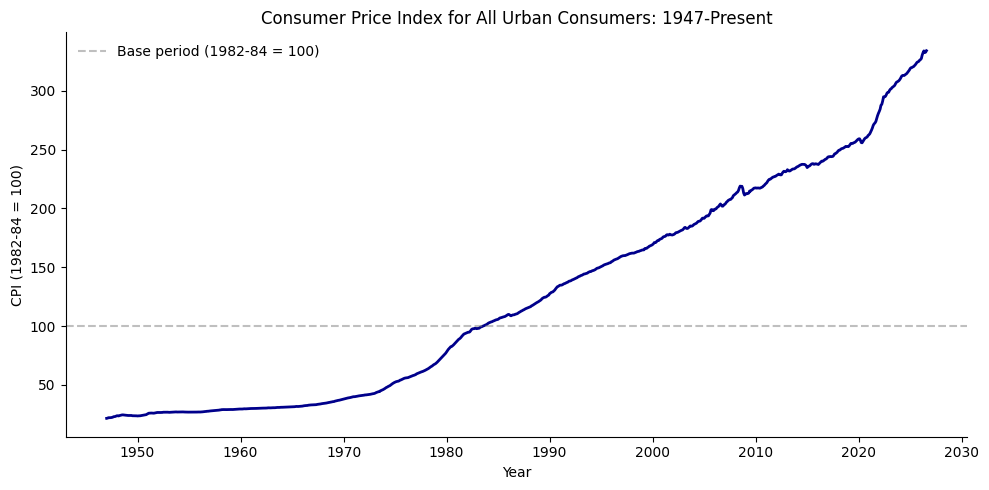

In [32]:
# -----------------------------------------------------------
# Step 2: Plot the CPI level over time
# This chart shows the LEVEL — how high prices are.
# The vibecession hook: consumers live at levels, not rates.
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(cpi.index, cpi["cpi"], color="darkblue", linewidth=2) # old_colour = #1565C0
ax.axhline(y=100, color="gray", linestyle="--", alpha=0.5,
           label="Base period (1982-84 = 100)")
ax.set_xlabel("Year")
ax.set_ylabel("CPI (1982-84 = 100)")
ax.set_title("Consumer Price Index for All Urban Consumers: 1947-Present")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

## Part 2: Building `deflate_series()` (GUIDED — 15 min)

This is your first reusable function in the course. You will use it again in Chapters 4, 12, 16, and 20.

The deflation formula: **Real Value = (Nominal Value / CPI) × Base-Year CPI**

<!-- idiom-note -->
> ### New idiom — reading a function definition, and `lambda`
>
> The cell below hands you a **function**: `def` names it, the indented lines
> are its body, and `return` sends a value back to whoever called it. You are
> not asked to write one yet — Lab 4 does that. For now, read `def
> deflate_series(nominal, cpi, base_year=2020):` as *"to deflate a series you
> need a nominal series, a CPI, and optionally a base year, which is 2020
> unless you say otherwise."*
>
> You will also meet `lambda` in this lab: `df["x"].map(lambda v: v / 1000)`
> is a one-expression function with no name, handed to `.map()` so it can be
> run once per value. Part 0 above used one. If it needs a name, use `def`;
> `lambda` exists for exactly this hand-it-to-something-else case.


In [5]:
#  IN CLASS -- TESTER 1:
def deflator(original_price, cpi):
  return original_price*(cpi/100) # the outcome

post_deflation = deflator(1, 315)
print(post_deflation)

3.15


In [6]:
# -----------------------------------------------------------
# Step 3: Build the deflate_series() function
# WHY: We need to convert nominal dollars to constant dollars
# so we can compare purchasing power across time.
# -----------------------------------------------------------

def deflate_series(nominal, cpi, base_year=2020):
    """
    Convert a nominal time series to real (constant-dollar) values.

    Parameters
    ----------
    nominal : pd.Series
        Nominal values indexed by date.
    cpi : pd.Series
        CPI values indexed by date (same frequency as nominal).
    base_year : int
        The year whose dollars you want to express values in.

    Returns
    -------
    pd.Series
        Real values in base_year dollars.
    """
    # Get average CPI in the base year for rescaling
    base_cpi = cpi.loc[cpi.index.year == base_year].mean()

    # Align on shared dates — drop any NaN from mismatched ranges
    aligned = pd.DataFrame({"nominal": nominal, "cpi": cpi}).dropna()

    # Deflate: divide by CPI, multiply by base-year CPI
    real = (aligned["nominal"] / aligned["cpi"]) * base_cpi
    real.name = f"real_{base_year}"

    return real

print("deflate_series() defined!")

deflate_series() defined!


In [7]:
# -----------------------------------------------------------
# Step 4: Quick test — deflate a single value
# Your grandfather earned $5,000 in 1970. What is that in 2020 dollars?
# -----------------------------------------------------------
cpi_1970 = cpi.loc[cpi.index.year == 1970, "cpi"].mean()
cpi_2020 = cpi.loc[cpi.index.year == 2020, "cpi"].mean()

real_value = (5000 / cpi_1970) * cpi_2020

print(f"CPI in 1970 (annual average): {cpi_1970:.1f}")
print(f"CPI in 2020 (annual average): {cpi_2020:.1f}")
print(f"$5,000 in 1970 = ${real_value:,.0f} in 2020 dollars")
# BOTH sides must be in the SAME dollars. $55,000 is a NOMINAL 2025 figure,
# so comparing it directly against a 2020-dollar number mixes two currencies
# and overstates the gain by roughly double.
cpi_2025 = cpi.loc[cpi.index.year == 2025, "cpi"].mean()
salary_today_in_2020_dollars = (55000 / cpi_2025) * cpi_2020

print(f"CPI in 2025 (annual average): {cpi_2025:.1f}")
print(f"$55,000 today = ${salary_today_in_2020_dollars:,.0f} in 2020 dollars")
print(f"\nComparing like with like, you are "
      f"{((salary_today_in_2020_dollars/real_value)-1)*100:.0f}% richer in real terms.")
print(f"Divide the nominal $55,000 by the 2020-dollar figure instead and you "
      f"get {((55000/real_value)-1)*100:.0f}% -- which is the units error this "
      f"whole chapter exists to prevent.")

CPI in 1970 (annual average): 38.8
CPI in 2020 (annual average): 258.9
$5,000 in 1970 = $33,322 in 2020 dollars
CPI in 2025 (annual average): 322.0
$55,000 today = $44,220 in 2020 dollars

Comparing like with like, you are 33% richer in real terms.
Divide the nominal $55,000 by the 2020-dollar figure instead and you get 65% -- which is the units error this whole chapter exists to prevent.


## Part 3: The Fifty-Year Wage Divergence (GUIDED — 10 min)

Now apply `deflate_series()` to nominal wages and see the divergence.

In [8]:
# -----------------------------------------------------------
# Step 5: Pull nominal average hourly earnings from FRED
# FRED series: AHETPI (Average Hourly Earnings, Total Private)
# -----------------------------------------------------------
wages_nominal = load_fred("AHETPI", start="1964-01-01")
wages_nominal.name = "nominal_wage"

# Pull CPI for same period
cpi_wages = load_fred("CPIAUCSL", start="1964-01-01")
cpi_wages.name = "cpi"

# Deflate!
wages_real = deflate_series(wages_nominal, cpi_wages, base_year=2020)

print(f"Nominal wage range: ${wages_nominal.iloc[0]:.2f} to ${wages_nominal.iloc[-1]:.2f}")
print(f"Real wage range: ${wages_real.iloc[0]:.2f} to ${wages_real.iloc[-1]:.2f} (2020 $)")

Nominal wage range: $2.50 to $32.53
Real wage range: $20.92 to $25.20 (2020 $)


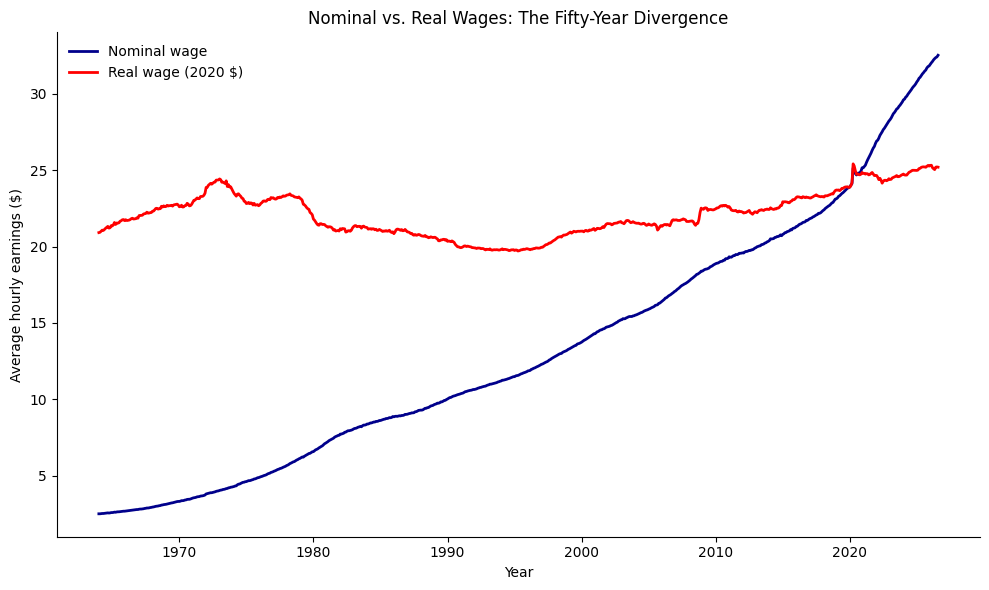

In [36]:
# -----------------------------------------------------------
# Step 6: Plot the divergence — the key chart of the chapter
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(wages_nominal.index, wages_nominal,
        label="Nominal wage", color="darkblue", linewidth=2) # old_colour = #2196F3
ax.plot(wages_real.index, wages_real,
        label="Real wage (2020 $)", color="red", linewidth=2) # old_colour = #FF9800
ax.set_xlabel("Year")
ax.set_ylabel("Average hourly earnings ($)")
ax.set_title("Nominal vs. Real Wages: The Fifty-Year Divergence")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Interpretation Question 2

Look at the chart above.

**Q1:** In approximately what year did real wages peak? What happened economically around that time?

**Q2:** If you only looked at the nominal (blue) line, would you conclude that workers' purchasing power has been rising? Why is this misleading?

**Q3:** This chart is the "vibecession" in one picture. Explain in 2-3 sentences why consumers in 2023 felt worse off even though CPI inflation was falling.

In [50]:
# HOMEWORK -- TESTER 1:
# maximum real wage:
print(wages_real.max()) # $25.417

# year of maximum real wage:
print(wages_real.idxmax().year) # 2020

25.417266415916757
2020


*Your answers here:*

**Q1:** The year that real wages peaked was ***2020***. Because back then, the pandemic eliminated a lot of low-wage jobs. Therefore, with the ***disappearance of low-wage workers***, the average wage among the workers that remained employed rised up.

**Q2:** If we only look at the nominal (blue) line, we cannot conclude that workers' purchasing power has been rising. It is misleading, because inflation exists, and ***nominal wage has to increase to catch up with inflation***. For example, if price rises faster than wages, workers will still earn more, but they actually have to buy less.

**Q3:** Consumers in 2023 felt worse off even though CPI inflation was falling, because inflation falling in 2023 just means that ***prices were increasing more slowly***, not that prices were returning back to their past levels. Also, after the time prices were increasing so much during the pandemic (around 2021-2022), people still had to face a much higher cost of living, so they would felt worse off even when inflation rate decreased.

## Part 4: Deflating the Big Mac (YOUR TURN — 10 min)

Now apply what you have learned. Load the Big Mac data from Lab 1 and deflate US
prices to see how much of the price increase is "real" and how much is inflation.

Three blanks in the next cell. Each one takes a single expression.

In [10]:
# -----------------------------------------------------------
# Step 7: Load Big Mac data (same URL from Ch 1)
# -----------------------------------------------------------
url = "https://raw.githubusercontent.com/TheEconomist/big-mac-data/master/output-data/big-mac-full-index.csv"
bigmac = pd.read_csv(url, parse_dates=["date"])

# Filter to United States only
us = bigmac[bigmac["name"] == "United States"][["date", "dollar_price"]].copy()
us = us.set_index("date").sort_index()
us.columns = ["bigmac_nominal"]

print(f"US Big Mac observations: {len(us)}")
print(f"Date range: {us.index.min().date()} to {us.index.max().date()}")
print(f"Price range: ${us['bigmac_nominal'].min():.2f} to ${us['bigmac_nominal'].max():.2f}")

US Big Mac observations: 45
Date range: 2000-04-01 to 2026-07-01
Price range: $2.24 to $6.22


In [14]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — Fill in the blanks
# Step 8: Deflate Big Mac prices to 2020 dollars
# -----------------------------------------------------------

# Step A (done for you): pull CPI from 2000 onward. No API key needed.
cpi_bm = load_fred("CPIAUCSL", start="2000-01-01")

# Step B (done for you): the Big Mac index is semi-annual and the CPI is
# monthly, so for each Big Mac date we take the most recent CPI reading at or
# before it. .asof() is what does that.
us["cpi"] = us.index.map(lambda d: cpi_bm.asof(d))

# Step C: the base-year CPI. Average every 2020 observation of cpi_bm.
#   Hint: this is the same one-liner Step 4 used, with cpi_bm in place of cpi.
#   HOMEWORK TASK 1:
base_cpi = cpi_bm.loc[cpi_bm.index.year == 2020].mean()

# Step D: deflate.  Real = (Nominal / CPI) * Base CPI
#   Hint: the nominal column is us["bigmac_nominal"] and the CPI column is
#   us["cpi"]. Whole columns divide element by element — no loop.
# HOMEWORK TASK 2:
bigmac_real = (us["bigmac_nominal"] / us["cpi"]) * base_cpi

us["bigmac_real"] = bigmac_real          # done for you

# Step E: the percentage change from the first observation to the last, for
#   each series. .iloc[-1] is the last row, .iloc[0] the first.
nominal_change = ((us["bigmac_nominal"].iloc[-1] / us["bigmac_nominal"].iloc[0]) - 1) * 100
# HOMEWORK TASK 3:
real_change = ((bigmac_real.iloc[-1] / bigmac_real.iloc[0]) - 1) * 100

print(f"Nominal change: {nominal_change:.0f}%")
print(f"Real change: {real_change:.0f}%")
cpi_change = ((us["cpi"].iloc[-1] / us["cpi"].iloc[0]) - 1) * 100   # done for you
print(f"CPI change over the same dates: {cpi_change:.0f}%")

Nominal change: 178%
Real change: 43%
CPI change over the same dates: 95%


In [15]:
# -----------------------------------------------------------
# CHECK — Run as-is after Step 8
# -----------------------------------------------------------
# 1. Units. A price in 2020 dollars, observed in 2020, is a 2020 price, so
#    real and nominal must agree in 2020 (to within a couple of percent: the
#    Big Mac dates use one month's CPI, the base uses the whole year).
in_2020 = us[us.index.year == 2020]
ratio = (in_2020["bigmac_real"] / in_2020["bigmac_nominal"]).mean()
assert 0.97 < ratio < 1.03, (
    f"In 2020 your real price is {ratio:.3f} times the nominal price; it should be "
    "about 1. A result near 0.004 means Base CPI is missing; near 0.39, the base is "
    "100 instead of the 2020 CPI.")

# 2. Base year. base_cpi should be the 2020 average, not one month.
cpi_2020 = cpi_bm[cpi_bm.index.year == 2020]
assert cpi_2020.min() <= base_cpi <= cpi_2020.max(), (
    f"base_cpi = {base_cpi:.2f} is not a 2020 CPI level.")
assert not (cpi_2020 == base_cpi).any(), (
    "base_cpi equals a single month's CPI; Step C asks for the 2020 average.")

# 3. The growth identity: (1 + nominal) = (1 + real) x (1 + CPI).
assert abs((1 + nominal_change / 100) - (1 + real_change / 100) * (1 + cpi_change / 100)) < 0.01, (
    "real_change is inconsistent with nominal_change and the CPI: "
    "(1 + nominal) should equal (1 + real) x (1 + CPI).")
print("Step 8 check passed: real prices are in 2020 dollars.")
print(f"  (1 + {nominal_change:.0f}%) = (1 + {real_change:.0f}%) x (1 + {cpi_change:.0f}%)")
print(f"  Subtracting instead: {nominal_change:.0f}% - {real_change:.0f}% = "
      f"{nominal_change - real_change:.0f} points, which is not the CPI's {cpi_change:.0f}%.")

Step 8 check passed: real prices are in 2020 dollars.
  (1 + 178%) = (1 + 43%) x (1 + 95%)
  Subtracting instead: 178% - 43% = 135 points, which is not the CPI's 95%.


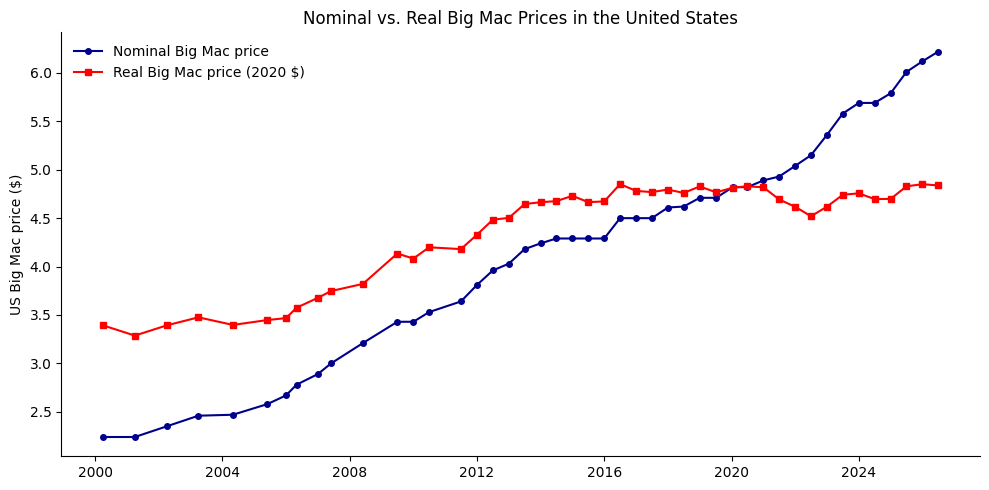

'\nThe version with the markers is more honest,\nbecause it accurately represents the prices of the Big Mac by the exact year,\n(for example, we know exactly which year the Big Mac price peaked).\n'

In [60]:
# -----------------------------------------------------------
# GUIDED — Run as-is (it needs Step 8 above to be filled in first)
# Step 9: Plot nominal vs. real Big Mac prices
# This is the wage divergence chart from Step 6, pointed at a burger.
# -----------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(us.index, us["bigmac_nominal"], marker="o", markersize=4,
        label="Nominal Big Mac price", color="darkblue", linewidth=1.5) # old colour = #2196F3
ax.plot(us.index, us["bigmac_real"], marker="s", markersize=4,
        label="Real Big Mac price (2020 $)", color="red", linewidth=1.5) # old colour = #FF9800

ax.set_ylabel("US Big Mac price ($)")
ax.set_title("Nominal vs. Real Big Mac Prices in the United States")
ax.legend(frameon=False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

# YOUR TASK: markers are used here (marker="o", marker="s") because the
# series is semi-annual — one point every six months, a few dozen in all. Change both
# markers to "" (no marker) and re-run. Write one sentence on which version
# is more honest about how much data actually exists.

# HOMEWORK -- ANSWER 1:
"""
The version with the markers is more honest,
because it accurately represents the prices of the Big Mac by the exact year,
(for example, we know exactly which year the Big Mac price peaked).
"""

### Interpretation Question 3

**Q1:** Your check printed three growth rates: nominal, real, and the CPI. Why is
*nominal minus real* not equal to the CPI's growth? Use the identity the check
printed, and say which of the three numbers is "inflation".

**Q2:** In Chapter 1, you compared Big Mac prices *across countries* (PPP). In this lab, you compared Big Mac prices *across time* (deflation). Both are index operations. What is the key difference between them?

**Q3:** A CEO tells shareholders: "Our revenue grew 15% this year." Inflation was 5%. What question should you ask, and what is the real growth rate?

In [65]:
# HOMEWORK -- TESTER 2:
# check the value of nominal_minus_real vs. CPI's growth:

# Iterate over the index of wages_real to ensure all series are aligned by date.
for date_idx in wages_real.index:
  # Access series elements by their date label using .loc
  # Use cpi_wages for consistency, as it was used to deflate nominal wages.
  nominal_minus_real = abs(wages_nominal.loc[date_idx] - wages_real.loc[date_idx])
  cpi_growth = cpi_wages.loc[date_idx]

  # check difference between nominal-minus-real and CPI's growth:
  diff = abs(nominal_minus_real - cpi_growth)

  # print results:
  print(nominal_minus_real, cpi_growth, diff)

18.415946186166767 30.94 12.524053813833234
18.43624636040116 30.91 12.47375363959884
18.48960997091143 30.94 12.45039002908857
18.556461712439415 30.95 12.393538287560585
18.53605196901226 30.98 12.443948030987741
18.58915664301837 31.01 12.420843356981631
18.65579642166344 31.02 12.36420357833656
18.70868478260869 31.05 12.341315217391312
18.761451737451736 31.08 12.318548262548262
18.660866404241638 31.12 12.459133595758363
18.672640820249917 31.21 12.537359179750084
18.791130719999998 31.25 12.458869280000002
18.770634111253194 31.28 12.509365888746807
18.843388507033243 31.28 12.436611492966758
18.968202091983386 31.31 12.341797908016613
18.847576481835556 31.38 12.532423518164443
18.92390295425667 31.48 12.556097045743332
18.907191474217015 31.61 12.702808525782984
18.92765112412919 31.58 12.652348875870807
19.020195879556255 31.55 12.529804120443746
19.04410934535104 31.62 12.575890654648962
19.095333175355446 31.65 12.554666824644553
19.098341811023616 31.75 12.651658188976384


*Your answers here:*

**Q1:** Nomimal minus real is not equal to CPI's growth, because CPI's growth rate is calculated by ***multiplying*** (not adding).

The number that represents "inflation" is ***CPI's growth***.

**Q2:** ***PPP compares purchasing power across countries at the same point in time***, using differences in price levels or exchange rates. But ***deflation compares purchasing power across different points in time within an economy***, using a price index like CPI's growth to convert nominal wages into real values.

**Q3:** We should ask if that 15% growth is nominal growth or inflation-adjusted real growth.

If it's real growth, then ***real growth = 15%***.

If it's nominal growth, and inflation was 𝛼, then ***real growth = 1.15 / (𝛼/100) - 1***.

---

## Part 5 (Optional — 10 min): The same data through the FRED API

Everything above used FRED's CSV endpoint, which needs no credential. Production
code usually uses the API instead, because it can search the catalogue, pull
metadata, and handle revisions — none of which a CSV URL can do. That route needs
the API key you set up at the top of this notebook.

**If you did not get a key, skip this part.** Nothing later depends on it.

The first cell below is a **guard**. It checks that you actually replaced the
placeholder before any request is made, and stops with a plain-English message if
you did not. Without a guard, the placeholder sails through, the setup cell prints
"Setup complete!", and the failure surfaces four cells later as thirty lines of
urllib traceback ending in `ValueError: Bad Request. The value for variable api_key
is not registered` — which tells you nothing about what to do.

In [27]:
# IN CLASS TESTER 2:
from google.colab import userdata
"""
print(userdata.get('FRED_API_KEY')) # NEED FIX
"""

"\nprint(userdata.get('FRED_API_KEY')) # NEED FIX\n"

In [28]:
# skip-run — needs your own FRED API key; the rest of the lab does not.
# -----------------------------------------------------------
# OPTIONAL — Part 5, cell 1: the guard
# -----------------------------------------------------------

FRED_API_KEY = "f7ba6baa2bace0088089bf1b29e2c6b4"   # <-- paste your key BETWEEN the quotes

if FRED_API_KEY.strip().upper() in {"YOUR_API_KEY_HERE", ""} or len(FRED_API_KEY) < 20:
    raise ValueError(
        "\n"
        "\n  No FRED API key found in this cell."
        "\n"
        "\n  You are still holding the placeholder. Nothing is broken and you have"
        "\n  not done anything wrong -- this cell simply has no key to send yet."
        "\n"
        "\n  To fix it:"
        "\n    1. Get a free key: https://fredaccount.stlouisfed.org/apikeys"
        "\n       (create an account, confirm the email, click Request API Key)"
        "\n    2. Copy the 32-character key FRED shows you."
        "\n    3. Come back to this cell and replace the words YOUR_API_KEY_HERE"
        "\n       with your key, leaving the quotation marks in place."
        "\n    4. Re-run this cell."
        "\n"
        "\n  Or skip Part 5 entirely. Parts 1-4 need no key and are the graded"
        "\n  content of this lab."
        "\n"
    )

print(f"Key accepted ({len(FRED_API_KEY)} characters). Ready for the API route.")

Key accepted (32 characters). Ready for the API route.


In [29]:
# skip-run — needs your own FRED API key.
# -----------------------------------------------------------
# OPTIONAL — Part 5, cell 2: the same CPI series, via fredapi
# -----------------------------------------------------------
# The ! line below is a shell command, not Python: it installs the fredapi
# package onto this Colab machine. Run it once per session.
!pip install fredapi -q

from fredapi import Fred

fred = Fred(api_key=FRED_API_KEY)
cpi_api = fred.get_series("CPIAUCSL", observation_start="1947-01-01")

print(f"Via the API:  {len(cpi_api)} observations, latest {cpi_api.iloc[-1]:.1f}")
print(f"Via the CSV:  {len(cpi):,} observations, latest {cpi['cpi'].iloc[-1]:.1f}")
print()
print("Same numbers, two doors. The API can also do what a CSV URL cannot:")
print(fred.search("unemployment rate", limit=3)[["title", "frequency"]].to_string())

Via the API:  956 observations, latest 334.1
Via the CSV:  955 observations, latest 334.1

Same numbers, two doors. The API can also do what a CSV URL cannot:
                                                     title frequency
series id                                                           
UNRATE                                   Unemployment Rate   Monthly
UNRATENSA                                Unemployment Rate   Monthly
LNS14000006  Unemployment Rate - Black or African American   Monthly


### Interpretation Question 4

**Q1:** Parts 1-4 pulled the same CPI series with no credential at all. Why does
FRED bother issuing API keys, if the data is free either way?

**Q2:** You are about to push this notebook to a public GitHub repository. What
should be sitting in the `FRED_API_KEY` line when you do, and what happens if your
real key is there instead?


*Your answers here:*

**Q1:** FRED issues API keys even though its data are free. Because the key identifies API users, allowing FRED to manage usage, enforce rate limits, and maintain reliable service. Some ways of downloading public FRED data don’t require authentication, while direct use of the FRED API does.

**Q2:** Before pushing to a public GitHub repository, the FRED_API_KEY line should contain no real credential:

```
FRED_API_KEY = os.getenv("FRED_API_KEY")
```
The actual key should be stored in an environment variable, or an ignored .env file. If we commit the real key, it becomes publicly exposed and could be copied and used by others under your credentials, so we should revoke or replace the key if that happens.

---
## AI-Assisted Expansion: Interactive Deflation Explorer

**The Generative AI Policy: Foundations First, Expansion Second.** You have now established manual mastery over pulling CPI from FRED, deflating nominal series, and reading real vs. nominal charts. You are now authorized to operate under the "Co-Pilot Rule."

### Your Expansion Task
Build an interactive explorer (ipywidgets + matplotlib, running inside Colab) that lets the user:
1. Choose a series — average hourly earnings or the US Big Mac price
2. Move a base-year slider and watch the real series relabel into that year's dollars
3. Toggle between nominal and real
4. Read the growth rate over the chosen window, which should NOT change with the base year

### P.R.I.M.E. Prompt
Copy and paste this into Claude or ChatGPT:

In [ ]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — Co-Pilot required
# Copy the P.R.I.M.E. prompt above into Claude, then paste
# the generated code here. Run it and verify.
# -----------------------------------------------------------

# [Prep] Act as an expert Python data scientist who teaches
# introductory economics with interactive notebooks.
#
# [Request] I just finished a lab where I pulled CPI from FRED
# with a load_fred() helper, deflated nominal wages with
# deflate_series(nominal, cpi, base_year), and deflated US Big
# Mac prices to 2020 dollars. Build an interactive explorer that
# runs inside Google Colab:
#   1. a dropdown to pick average hourly earnings
#      (wages_nominal, deflated with cpi_wages) or the
#      US Big Mac price (us["bigmac_nominal"])
#   2. a base-year slider (2000-2025) that re-deflates the series
#   3. a nominal / real toggle
#   4. a text readout of the percentage change from the first to
#      the last observation, in both nominal and real terms
#
# [Iterate] Use ipywidgets and matplotlib only. Reuse my
# variables and functions: load_fred, deflate_series, cpi_bm,
# cpi_wages, wages_nominal, wages_real, us. Do not use deprecated pandas functions.
#
# [Mechanism Check] Add inline comments explaining:
#   - why moving the base year changes the dollar LEVEL of the
#     real series but not its growth rate
#   - why the Big Mac series needs .asof() to line up with the
#     monthly CPI
#   - how the widget callback redraws the chart
#
# [Evaluate] Explain what the explorer shows about the claim
# "real wages have been flat for fifty years".

# PASTE AI-GENERATED CODE BELOW:

In [63]:
# credits to Claude (haven't understood yet, will learn later)
# DEBUGGING...

# =============================================================
# Interactive Real vs. Nominal Wage / Big Mac Price Explorer
# (built for Google Colab; reuses variables from the earlier lab)
# =============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider, ToggleButtons
from IPython.display import display

# -------------------------------------------------------------
# 1. Build a small registry of the two series we can explore.
#    Each entry stores the NOMINAL series and the CPI series
#    that should be used to deflate it, since wages and the
#    Big Mac price are benchmarked against different CPI pulls
#    (cpi_wages vs. cpi_bm) in the earlier lab cells.
# -------------------------------------------------------------
series_registry = {
    "Average Hourly Earnings (wages)": {
        "nominal": wages_nominal,
        "cpi": cpi_wages,
    },
    "US Big Mac Price": {
        "nominal": us["bigmac_nominal"],
        "cpi": cpi_bm,
    },
}

# -------------------------------------------------------------
# 2. Widgets
# -------------------------------------------------------------
series_dropdown = Dropdown(
    options=list(series_registry.keys()),
    value="Average Hourly Earnings (wages)",
    description="Series:",
    style={"description_width": "initial"},
)

base_year_slider = IntSlider(
    value=2020, min=2000, max=2025, step=1,
    description="Base year:",
    style={"description_width": "initial"},
    continuous_update=False,  # only redraw on release -> snappier in Colab
)

nominal_real_toggle = ToggleButtons(
    options=["Nominal", "Real"],
    value="Real",
    description="Show:",
    style={"description_width": "initial"},
)

output = widgets.Output()

# -------------------------------------------------------------
# 3. The callback that redraws the chart.
#    ipywidgets' `interact`/`observe` machinery works by re-calling
#    this function every time ANY of the linked widgets fires a
#    'value changed' trait event. We don't manage that plumbing
#    ourselves -- interact() inspects the function's keyword
#    arguments, matches each one to a widget, and wires up the
#    observers automatically. Each call clears the previous plot
#    (output.clear_output) and redraws from scratch rather than
#    mutating the existing Matplotlib artists, which is simpler
#    to reason about at the cost of a small redraw flicker.
# -------------------------------------------------------------
def update_plot(series_name, base_year, mode):
    entry = series_registry[series_name]
    nominal = entry["nominal"]
    cpi = entry["cpi"]

    # ---- Big Mac alignment ------------------------------------------------
    # The Big Mac price is observed at irregular / sparse dates (survey
    # data collected a few times a year), while CPI is a regular monthly
    # series. A plain merge on exact dates would drop almost every Big Mac
    # observation because the dates rarely coincide. `.asof()` instead
    # walks backward from each Big Mac date to the most recent CPI reading
    # on or before it, so every Big Mac price gets matched to "the CPI that
    # was in effect at the time" rather than being lost to a failed join.
    # We apply this defensively for any irregular series in the registry.
    cpi_sorted = cpi.sort_index()
    nominal_sorted = nominal.sort_index()
    aligned_cpi = cpi_sorted.reindex(nominal_sorted.index, method=None)
    if aligned_cpi.isna().any():
        # fall back to asof-alignment when exact-date CPI values are missing
        aligned_cpi = pd.Series(
            [cpi_sorted.asof(d) for d in nominal_sorted.index],
            index=nominal_sorted.index,
        )

    # ---- Deflate using the student's own helper ---------------------------
    real = deflate_series(nominal_sorted, aligned_cpi, base_year)

    # Why changing base_year moves the LEVEL but not the GROWTH RATE:
    # deflate_series computes  real_t = nominal_t * (cpi[base_year] / cpi_t).
    # cpi[base_year] is a single scalar multiplier applied identically to
    # every t. Scaling an entire series by one constant shifts all values
    # up or down together (changes the level / which year reads "$X"),
    # but the RATIO real_t / real_{t-1} is unchanged, because the constant
    # cancels out of that ratio. So % changes, growth rates, and the shape
    # of the curve are identical for any base year -- only the y-axis
    # units ("in 2020 dollars" vs "in 2010 dollars") change.
    series_to_plot = nominal_sorted if mode == "Nominal" else real
    label = f"{series_name} ({mode}" + (f", base {base_year})" if mode == "Real" else ")")

    # ---- % change from first to last observation, nominal AND real -------
    pct_nominal = (nominal_sorted.iloc[-1] / nominal_sorted.iloc[0] - 1) * 100
    pct_real = (real.iloc[-1] / real.iloc[0] - 1) * 100

    with output:
        output.clear_output(wait=True)
        fig, ax = plt.subplots(figsize=(9, 5))
        ax.plot(series_to_plot.index, series_to_plot.values, lw=2)
        ax.set_title(label)
        ax.set_xlabel("Date")
        ax.set_ylabel("Dollars" + (f" (base year {base_year})" if mode == "Real" else " (as reported)"))
        ax.grid(alpha=0.3)
        plt.show()

        print(f"From {nominal_sorted.index[0].date()} to {nominal_sorted.index[-1].date()}:")
        print(f"  Nominal change: {pct_nominal:+.1f}%")
        print(f"  Real change (base {base_year}):    {pct_real:+.1f}%")

# -------------------------------------------------------------
# 4. Wire the widgets to the callback and display everything.
#    interact() binds series_dropdown -> series_name,
#    base_year_slider -> base_year, nominal_real_toggle -> mode
#    by matching argument names, and triggers update_plot()
#    once immediately plus again on every subsequent change.
# -------------------------------------------------------------
ui = widgets.VBox([series_dropdown, base_year_slider, nominal_real_toggle, output])
display(ui)

interact(
    update_plot,
    series_name=series_dropdown,
    base_year=base_year_slider,
    mode=nominal_real_toggle,
)

interactive(children=(Dropdown(description='Series:', options=('Average Hourly Earnings (wages)', 'US Big Mac …

<function __main__.update_plot(series_name, base_year, mode)>

### Document the interaction

Three short answers. This is what is graded for the expansion, not the code.

1. **What did the AI get wrong or leave out?** Name one line you had to change,
   or one claim in its explanation that your own output contradicts.
2. **How did you verify it?** Point to a number the dashboard shows that you
   also computed by hand earlier in this lab, and say whether they match.
3. **What would you ask differently next time?**

*Your answers here:*

1.
2.
3.

## Part 6: Write your README

Your README is what a reader sees before they open a single cell. Draft it with
the README prompt in the Digital Portfolio section below, then check every
number in the draft against your own output.

---
## Digital Portfolio: Institutional Signaling

### Generate Your Professional README
Copy and paste the prompt below into Claude or ChatGPT. **Do NOT ask the AI to write Python code — only documentation.** Replace every `[YOUR VALUE]` with the number from your own output before you paste it.

In [64]:
# -----------------------------------------------------------
# 🤖 AI EXPANSION — README generation (no code, just docs)
# -----------------------------------------------------------

# PASTE THIS PROMPT INTO CLAUDE:
#
# "I need help writing a project description for my data science lab.
# **Important Rule:** Do NOT generate any Python code for me.
#
# **What I did in this lab:**
# * Pulled CPI and average hourly earnings from FRED with no API key
# * Wrote deflate_series() and converted wages to constant 2020 dollars
# * Showed nominal hourly earnings rose from $[YOUR VALUE] to $[YOUR VALUE]
#   while real earnings moved from $[YOUR VALUE] to $[YOUR VALUE]
# * Deflated the US Big Mac price: nominal +[YOUR VALUE]%, real
#   +[YOUR VALUE]%, CPI +[YOUR VALUE]% over the same dates
# * Built an interactive deflation explorer with a base-year slider
#
# **Please write a README.md entry including:**
# 1. Project Title: Deflating Economic Data — Nominal vs. Real
# 2. Objective: A professional one-sentence summary
# 3. Methodology: Bullet points of technical steps
# 4. Key Findings: Summary of results
# Make this sound like a professional tech economist wrote it."

---

## Submit this lab on GitHub

**Repository name for this lab:** `econ3916-lab02-deflation`

**First time?** Read the **GitHub Setup** page in the Start Here module once,
start to finish. It assumes you have never used git and never seen GitHub.

1. On [github.com](https://github.com): **+** (top right) → **New repository**.
   Name it exactly `econ3916-lab02-deflation`, tick **Add a README file**, and create it.
2. In Colab: **File → Save a copy in GitHub**. Choose `econ3916-lab02-deflation`, branch `main`,
   commit message `Lab 02 submission`. This pushes the notebook, and the
   notebook's rendered output — charts included — is what is graded.
3. Open the repo on github.com, click `README.md`, then the pencil icon, and
   paste in the README you drafted from the README prompt above. **Commit
   changes.** Check every number in it against your own output first: this
   goes out under your name.
4. On Canvas: in Colab use **File → Download → Download .ipynb**, upload that
   file to the assignment, and paste your repository URL in the **Comments**
   box beside the upload. Then click **Submit**. Do not use the Website URL
   tab: Canvas keeps one submission, so a URL sent on its own replaces your
   notebook.

No terminal, no token, nothing to install.

---

**Lab 2 complete!** You now have a reusable `deflate_series()` function that you will use throughout this course. Remember: never compare monetary values across time without deflating first.